In [2]:
import matplotlib.pyplot as plt

try:
    plt.style.use('seaborn-whitegrid')
except:
    plt.style.use('seaborn-v0_8-whitegrid')
    
plt.rc('figure', autolayout=True)
plt.rc(
    'axes',
    labelweight='bold',
    labelsize='large',
    titleweight='bold',
    titlesize=18,
    titlepad=10
)


In [4]:
import pandas as pd

red_wine = pd.read_csv('../dataset/wine_quality.csv')
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
red_wine.shape

(55, 12)

## Input Shape

How well can we predict a wine's perceived quality from the physiochemical measurements?

The target is `'quality'`, and the remaining columns are the features. How would you set the `input_shape` parameter for a Keras model on this task?

In [6]:
input_shape = [11]


The input shape for this wine quality dataset is **[11]**.

This is because:

- The dataset has 12 columns total
- 1 column is the target (`'quality'`)
- The remaining **11 columns** are the features (fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol)

So when creating a Keras model, you would set `input_shape=[11]` or `input_shape=(11,)` for the first layer, indicating that each input sample has 11 features.

## Define a Linear Model

Now define a linear model appropriate for this task. Pay attention to how many inputs and outputs the model should have.

In [17]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(units=1, input_shape=input_shape)
])

## Look at the Weights

Internally, Keras represents the weights of a neural network with **tensors**. Tensors are basically TensorFlow's version of a Numpy array with a few differences that make them better suited to deep learning. One of the most important is that tensors are compatible with [GPU](https://www.kaggle.com/docs/efficient-gpu-usage) and [TPU](https://www.kaggle.com/docs/tpu) accelerators. TPUs, in fact, are designed specifically for tensor computations.

A model's weights are kept in its `weights` attribute as a list of tensors. Get the weights of the model you defined above. (If you want, you could display the weights with something like: `print("Weights\n{}\n\nBias\n{}".format(w, b))`).

In [18]:
w, b = model.weights

print("Weights:")
print(w.numpy())
print("\nBias:")
print(b.numpy())

Weights:
[[ 0.55899435]
 [ 0.6560405 ]
 [ 0.5679694 ]
 [ 0.6895922 ]
 [ 0.52994186]
 [ 0.54657143]
 [ 0.3023762 ]
 [ 0.3267445 ]
 [ 0.07692134]
 [-0.40874687]
 [ 0.36566335]]

Bias:
[0.]


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


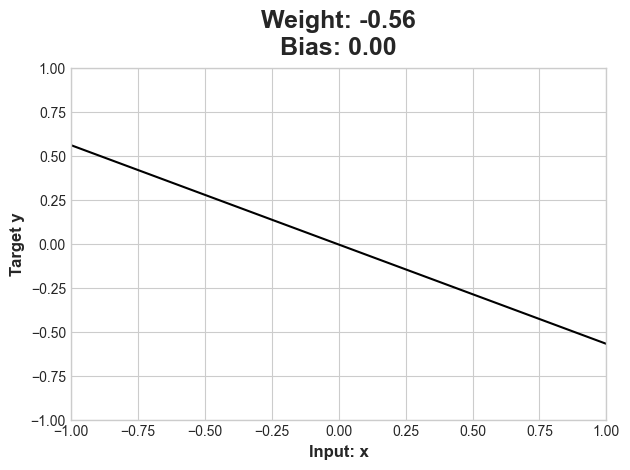

In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Create a separate demo model for visualization
demo_model = keras.Sequential([
    layers.Dense(1, input_shape=[1]),
])

x = tf.linspace(-1.0, 1.0, 100)
y = demo_model.predict(x)

plt.figure(dpi=100)
plt.plot(x, y, 'k')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel("Input: x")
plt.ylabel("Target y")
w_demo, b_demo = demo_model.weights
plt.title("Weight: {:0.2f}\nBias: {:0.2f}".format(w_demo[0][0], b_demo[0]))
plt.show()

## Train the Model

Now let's train the model on the wine quality dataset. We'll split the data into three sets:

1. **Training set (70%)**: Used to train the model - the model learns from this data
2. **Validation set (15%)**: Used during training to monitor performance and tune hyperparameters
3. **Test set (15%)**: Held out completely until the end to evaluate final model performance on unseen data

This ensures we get an unbiased estimate of how well our model will perform on new, unseen data.

In [23]:
import numpy as np

# Prepare the data: separate features (X) and target (y)
X = red_wine.drop('quality', axis=1)
y = red_wine['quality']

# Shuffle the data
shuffled_indices = np.random.RandomState(42).permutation(len(X))
X_shuffled = X.iloc[shuffled_indices].reset_index(drop=True)
y_shuffled = y.iloc[shuffled_indices].reset_index(drop=True)

# Split into train (70%), validation (15%), and test (15%)
n_samples = len(X_shuffled)
train_end = int(0.70 * n_samples)
val_end = int(0.85 * n_samples)

X_train = X_shuffled[:train_end]
y_train = y_shuffled[:train_end]

X_val = X_shuffled[train_end:val_end]
y_val = y_shuffled[train_end:val_end]

X_test = X_shuffled[val_end:]
y_test = y_shuffled[val_end:]

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTotal: {len(X_train) + len(X_val) + len(X_test)} samples")

Training set: 38 samples
Validation set: 8 samples
Test set: 9 samples

Total: 55 samples


In [24]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='mae',  # Mean Absolute Error
    metrics=['mae', 'mse']  # Track both MAE and MSE during training
)

print("Model compiled successfully!")

Model compiled successfully!


In [25]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),  # Use explicit validation set
    verbose=1
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 659ms/step - loss: 36.4320 - mae: 36.4320 - mse: 1996.1320 - val_loss: 32.1998 - val_mae: 32.1998 - val_mse: 1244.4059
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 36.2028 - mae: 36.2028 - mse: 1971.0411 - val_loss: 31.9891 - val_mae: 31.9891 - val_mse: 1228.3741
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 35.9793 - mae: 35.9793 - mse: 1948.6334 - val_loss: 31.7771 - val_mae: 31.7771 - val_mse: 1212.3401
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - loss: 35.7511 - mae: 35.7511 - mse: 1924.2115 - val_loss: 31.5643 - val_mae: 31.5643 - val_mse: 1196.3525
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 35.5320 - mae: 35.5320 - mse: 1902.6703 - val_loss: 31.3525 - val_mae: 31.3525 - val_mse: 1180.5419
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 35.2915 - mae: 35.2915 - mse: 1875.4430 - val_loss: 31.1418 - val_mae: 31.1418 - val_mse: 1164.9329
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/

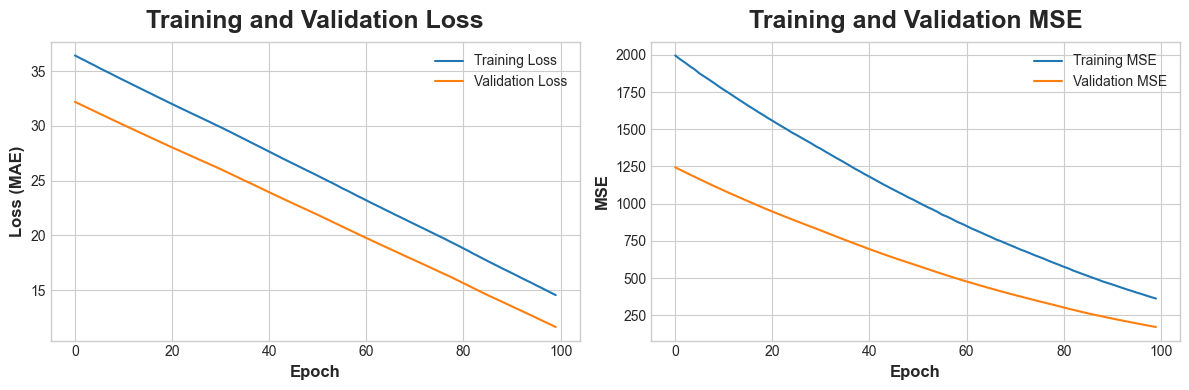

In [26]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mse'], label='Training MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training and Validation MSE')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# Check the trained weights
w_trained, b_trained = model.weights

print("Trained Weights:")
print(w_trained.numpy())
print("\nTrained Bias:")
print(b_trained.numpy())

Trained Weights:
[[ 0.35926184]
 [ 0.45713374]
 [ 0.37579364]
 [ 0.49771914]
 [ 0.33310926]
 [ 0.34994465]
 [ 0.10861193]
 [ 0.1267383 ]
 [-0.1231861 ]
 [-0.6064898 ]
 [ 0.16589849]]

Trained Bias:
[-0.19999827]


## Evaluate on Test Set

Now let's evaluate the model on the test set - data it has never seen during training or validation. This gives us an unbiased estimate of how well the model will perform on new data.

In [28]:
# Evaluate on test set
test_loss, test_mae, test_mse = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss (MAE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test RMSE: {test_mse**0.5:.4f}")

# Make some predictions on test set
predictions = model.predict(X_test[:5])
print("\nSample Predictions vs Actual:")
for i in range(5):
    print(f"Predicted: {predictions[i][0]:.2f}, Actual: {y_test.iloc[i]}")

Test Loss (MAE): 13.7828
Test MAE: 13.7828
Test MSE: 272.2610
Test RMSE: 16.5003
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

Sample Predictions vs Actual:
Predicted: 16.64, Actual: 6
Predicted: 24.77, Actual: 6
Predicted: 20.67, Actual: 5
Predicted: 9.94, Actual: 7
Predicted: 20.49, Actual: 6
